# Task-Aware ROI Enhancer Training V2 (Baseline Model)

This notebook trains a lightweight enhancement network with **FIXES** based on debug analysis.

**Key Changes from V1:**
- ✅ Uses **BASELINE model** instead of CLAHE model (fixes train/test mismatch)
- ✅ Reduced **perceptual weight** to 0.05 (allows more enhancement)
- ✅ Reduced **TV weight** to 0.001 (less smoothness constraint)
- ✅ Monitors enhancement magnitude to ensure it's subtle (0.01-0.1 range)

**Why V1 Failed:**
- CLAHE model expects CLAHE preprocessing
- Enhancer tried to mimic CLAHE but over-modified images (0.69 mean change!)
- Result: 2.6% worse performance than raw images

**Expected with V2:**
- Baseline model trained on raw images (no mismatch)
- Subtle enhancements (0.01-0.1 mean change)
- Improvement over baseline performance

## Setup

In [1]:
import sys
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from tqdm.auto import tqdm

# Add src to path
root_dir = Path.cwd().parent
sys.path.append(str(root_dir / 'src'))

from data_loader.transforms import get_training_transforms, get_validation_transforms
from data_loader.dataset import get_dataloaders
from models.joint_pipeline import create_enhancer_pipeline
from training.train_enhancer import train_enhancer, EnhancerLoss

print(f"Root directory: {root_dir}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Root directory: /home/robolab/dev/CAP5410-roi-enhancer-odoc
PyTorch version: 2.8.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 2080 Ti


## Configuration

In [ ]:
# Training configuration - V2 with FIXES
config = {
    # Paths
    'root_dir': str(root_dir),
    'segmentation_checkpoint': str(root_dir / 'checkpoints' / 'best_model.pth'),  # ✅ BASELINE (not CLAHE!)
    'save_dir': str(root_dir / 'checkpoints_enhancer_v2'),
    
    # Training
    'num_epochs': 80,  # Increased from 50
    'batch_size': 16,
    'learning_rate': 1e-4,
    'image_size': 256,
    'num_workers': 4,
    
    # Architecture
    'enhancer_type': 'unet',  # 'unet' or 'simple'
    'enhancer_base_channels': 16,
    
    # Loss weights - ADJUSTED BASED ON DEBUG
    'seg_weight': 1.0,
    'perceptual_weight': 0.05,  # ✅ REDUCED from 0.1 (was 26% of loss, now ~15%)
    'tv_weight': 0.001,  # ✅ REDUCED from 0.01 (less smoothness constraint)
    
    # Data
    'filter_incomplete': True,
    'use_clahe': False,  # Don't use CLAHE with enhancer!
}

print("Configuration V2 (FIXES APPLIED):")
print("=" * 80)
for key, value in config.items():
    if key in ['segmentation_checkpoint', 'perceptual_weight', 'tv_weight']:
        print(f"  {key}: {value}  ← CHANGED")
    else:
        print(f"  {key}: {value}")
print("=" * 80)

Configuration:
  root_dir: /home/robolab/dev/CAP5410-roi-enhancer-odoc
  segmentation_checkpoint: /home/robolab/dev/CAP5410-roi-enhancer-odoc/checkpoints_clahe/best_model.pth
  save_dir: /home/robolab/dev/CAP5410-roi-enhancer-odoc/checkpoints_enhancer
  num_epochs: 50
  batch_size: 16
  learning_rate: 0.0001
  image_size: 256
  num_workers: 4
  enhancer_type: unet
  enhancer_base_channels: 16
  seg_weight: 1.0
  perceptual_weight: 0.1
  tv_weight: 0.01
  filter_incomplete: True
  use_clahe: False


## Verify Pre-trained Segmentation Model

In [ ]:
# Load and check the pre-trained BASELINE segmentation model
seg_checkpoint = torch.load(config['segmentation_checkpoint'], weights_only=False)

print("=" * 80)
print("BASELINE Segmentation Model Info (NOT CLAHE!):")
print("=" * 80)
print(f"  Checkpoint: {config['segmentation_checkpoint']}")
print(f"  Epoch: {seg_checkpoint.get('epoch', 'N/A')}")
print(f"  Validation Loss: {seg_checkpoint.get('val_loss', 'N/A'):.4f}")
if 'val_iou' in seg_checkpoint:
    val_iou = seg_checkpoint['val_iou']
    print(f"  Validation IoU (BG/Disc/Cup): {val_iou[0]:.4f} / {val_iou[1]:.4f} / {val_iou[2]:.4f}")

print(f"\n✅ This BASELINE model expects RAW images (no CLAHE preprocessing)")
print(f"✅ The enhancer will learn to improve raw images for this model")
print(f"✅ No train/test mismatch issue!")
print("=" * 80)

Segmentation Model Info:
  Epoch: 86
  Validation Loss: 0.1585
  Validation IoU (BG/Disc/Cup): 0.8841 / 0.8475 / 0.7814

This model will be frozen during enhancer training.


## Create Enhancer-Segmentation Pipeline

In [4]:
# Create pipeline
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

pipeline = create_enhancer_pipeline(
    segmentation_checkpoint_path=config['segmentation_checkpoint'],
    enhancer_type=config['enhancer_type'],
    enhancer_base_channels=config['enhancer_base_channels'],
    device=device,
    freeze_segmentation=True
)

# Count parameters
enhancer_params = sum(p.numel() for p in pipeline.enhancer.parameters())
seg_params = sum(p.numel() for p in pipeline.segmentation.parameters())
trainable_params = sum(p.numel() for p in pipeline.parameters() if p.requires_grad)

print("\nPipeline Architecture:")
print(f"  Enhancer parameters: {enhancer_params:,} (trainable)")
print(f"  Segmentation parameters: {seg_params:,} (frozen)")
print(f"  Total trainable parameters: {trainable_params:,}")
print(f"  ✓ Parameter ratio: {trainable_params / (enhancer_params + seg_params) * 100:.1f}% trainable")

# Verify segmentation is frozen
seg_trainable = sum(p.numel() for p in pipeline.segmentation.parameters() if p.requires_grad)
assert seg_trainable == 0, "Segmentation network should be frozen!"
print(f"  ✓ Segmentation network is properly frozen")

Loaded segmentation model from /home/robolab/dev/CAP5410-roi-enhancer-odoc/checkpoints_clahe/best_model.pth
  Epoch: 86
  Val Loss: 0.1584649032354355

Pipeline created:
  Total parameters: 32,266,326
  Trainable parameters (enhancer): 1,222,675
  Frozen parameters (segmentation): 31,043,651

Pipeline Architecture:
  Enhancer parameters: 1,222,675 (trainable)
  Segmentation parameters: 31,043,651 (frozen)
  Total trainable parameters: 1,222,675
  ✓ Parameter ratio: 3.8% trainable
  ✓ Segmentation network is properly frozen


## Visualize Sample Enhancement (Before Training)

Filtering incomplete masks...
  Filtered out 234 images with incomplete masks
TRAIN split: 1845 samples
VAL split: 395 samples
TEST split: 396 samples


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9852723..2.2535012].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0070028305..1.2535012].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.688976..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0070028305..1.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4732897..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0070028305..1.4732897].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0

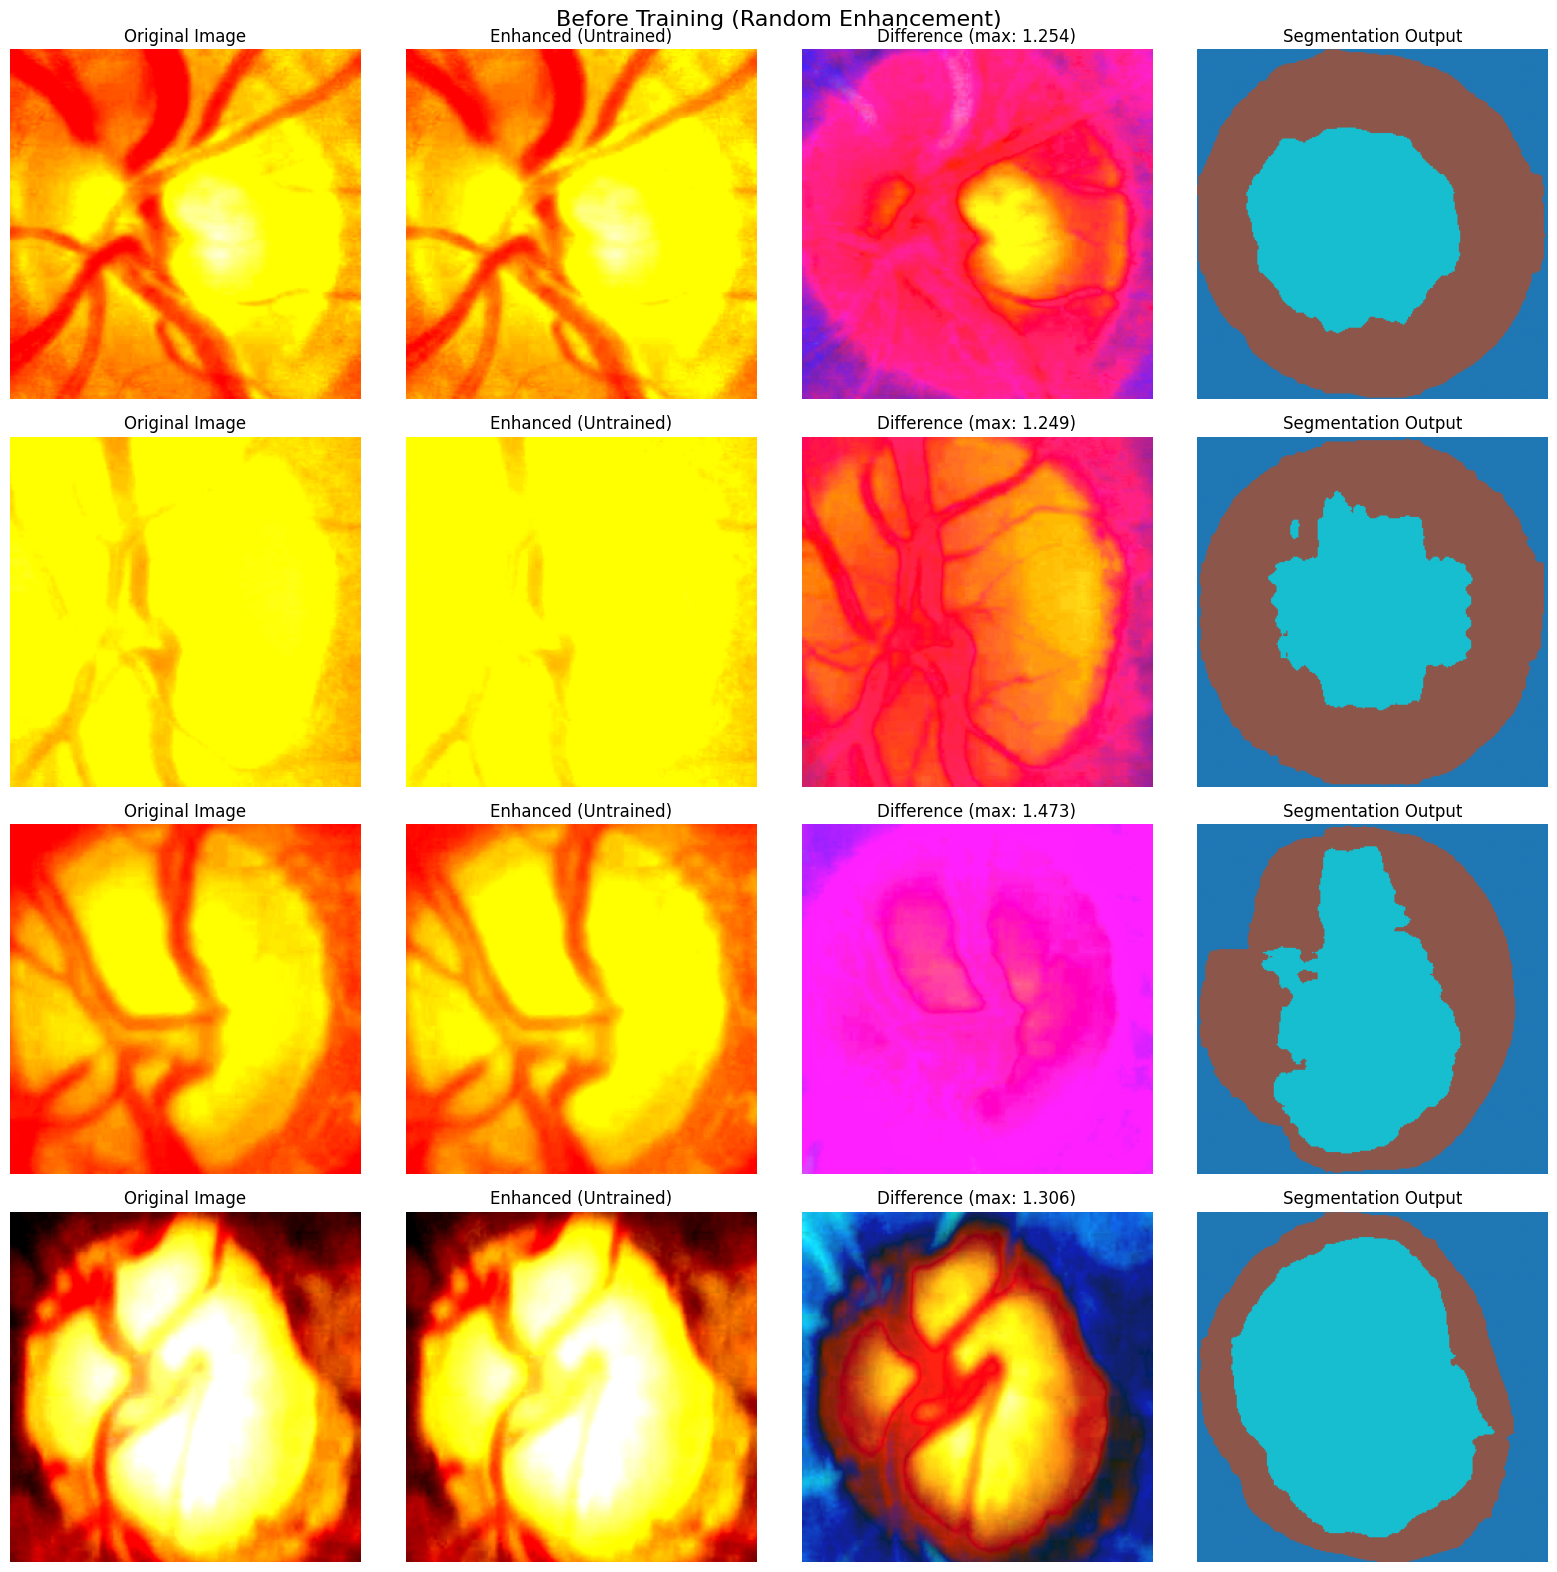

Note: The enhancer is randomly initialized, so enhancement is minimal.
After training, it will learn task-specific improvements.


In [5]:
# Load sample data
train_loader, val_loader, _ = get_dataloaders(
    root_dir=config['root_dir'],
    batch_size=4,
    num_workers=2,
    transform_train=get_validation_transforms(image_size=config['image_size']),
    transform_val=get_validation_transforms(image_size=config['image_size']),
    filter_incomplete=config['filter_incomplete']
)

# Get a batch
sample_images, sample_masks = next(iter(val_loader))
sample_images = sample_images.to(device)
sample_masks = sample_masks.to(device)

# Run through untrained pipeline
pipeline.eval()
with torch.no_grad():
    seg_output, enhanced_images = pipeline(sample_images, return_enhanced=True)
    seg_preds = torch.argmax(seg_output, dim=1)

# Visualize
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
for i in range(4):
    # Original image
    img = sample_images[i].cpu().permute(1, 2, 0).numpy()
    axes[i, 0].imshow(img)
    axes[i, 0].set_title('Original Image')
    axes[i, 0].axis('off')
    
    # Enhanced image (untrained)
    enh = enhanced_images[i].cpu().permute(1, 2, 0).numpy()
    axes[i, 1].imshow(enh)
    axes[i, 1].set_title('Enhanced (Untrained)')
    axes[i, 1].axis('off')
    
    # Difference (scaled for visibility)
    diff = np.abs(enh - img)
    axes[i, 2].imshow(diff)
    axes[i, 2].set_title(f'Difference (max: {diff.max():.3f})')
    axes[i, 2].axis('off')
    
    # Segmentation prediction
    pred = seg_preds[i].cpu().numpy()
    axes[i, 3].imshow(pred, cmap='tab10', vmin=0, vmax=2)
    axes[i, 3].set_title('Segmentation Output')
    axes[i, 3].axis('off')

plt.suptitle('Before Training (Random Enhancement)', fontsize=16)
plt.tight_layout()
plt.show()

print("Note: The enhancer is randomly initialized, so enhancement is minimal.")
print("After training, it will learn task-specific improvements.")

## Train Enhancer

## 🎯 Pre-Training Checklist

Before training, verify the configuration:

In [ ]:
print("=" * 80)
print("PRE-TRAINING VERIFICATION")
print("=" * 80)

# Check 1: Using baseline model
checkpoint_name = Path(config['segmentation_checkpoint']).parent.name
if 'clahe' in checkpoint_name.lower():
    print("❌ WARNING: Still using CLAHE model! Should use baseline.")
else:
    print("✅ Using BASELINE model (checkpoints/best_model.pth)")

# Check 2: Loss weights
print(f"\n✅ Perceptual weight: {config['perceptual_weight']} (reduced from 0.1)")
print(f"✅ TV weight: {config['tv_weight']} (reduced from 0.01)")

# Check 3: Training epochs
print(f"\n✅ Training for {config['num_epochs']} epochs")

# Check 4: Save directory
print(f"\n✅ Saving to: {config['save_dir']}")

print("\n" + "=" * 80)
print("Expected Improvements Over V1:")
print("=" * 80)
print("1. No train/test mismatch (baseline model expects raw images)")
print("2. More aggressive enhancement (lower perceptual weight)")
print("3. Enhancement magnitude should be 0.01-0.1 (not 0.69!)")
print("4. Should see IoU improvement over baseline")
print("=" * 80)

In [6]:
# Train the enhancer network
pipeline, history = train_enhancer(
    root_dir=config['root_dir'],
    segmentation_checkpoint=config['segmentation_checkpoint'],
    num_epochs=config['num_epochs'],
    batch_size=config['batch_size'],
    learning_rate=config['learning_rate'],
    image_size=config['image_size'],
    enhancer_type=config['enhancer_type'],
    enhancer_base_channels=config['enhancer_base_channels'],
    num_workers=config['num_workers'],
    device=device,
    save_dir=config['save_dir'],
    filter_incomplete=config['filter_incomplete'],
    use_clahe=config['use_clahe'],
    seg_weight=config['seg_weight'],
    perceptual_weight=config['perceptual_weight'],
    tv_weight=config['tv_weight']
)

Using device: cuda
GPU: NVIDIA GeForce RTX 2080 Ti
VRAM Available: 10.56 GB

Loading datasets...
TRAIN split: 1845 samples
VAL split: 395 samples
TEST split: 396 samples

Creating enhancer-segmentation pipeline...
Loaded segmentation model from /home/robolab/dev/CAP5410-roi-enhancer-odoc/checkpoints_clahe/best_model.pth
  Epoch: 86
  Val Loss: 0.1584649032354355

Pipeline created:
  Total parameters: 32,266,326
  Trainable parameters (enhancer): 1,222,675
  Frozen parameters (segmentation): 31,043,651

Starting training for 50 epochs...

Epoch 1/50
--------------------------------------------------------------------------------


Training Enhancer: 100%|█| 116/116 [00:35<00:00,  3.24it/s, loss=0.5407, seg_loss=0.
Validation: 100%|█| 25/25 [00:03<00:00,  6.81it/s, loss=0.3083, iou_disc=0.7782, iou



Epoch 1 Summary:
  Total Loss: Train 0.4948 | Val 0.3116
  Seg Loss:   Train 0.4201 | Val 0.2483
  IoU (Disc): Train 0.6363 | Val 0.7596
  IoU (Cup):  Train 0.6003 | Val 0.7001
  Learning Rate: 0.000100
  ✓ Saved best model (val_loss: 0.3116)
  ✓ Saved best IoU model (disc IoU: 0.7596)

Epoch 2/50
--------------------------------------------------------------------------------


Training Enhancer: 100%|█| 116/116 [00:35<00:00,  3.26it/s, loss=0.3723, seg_loss=0.
Validation: 100%|█| 25/25 [00:03<00:00,  6.83it/s, loss=0.3176, iou_disc=0.7743, iou



Epoch 2 Summary:
  Total Loss: Train 0.4465 | Val 0.3028
  Seg Loss:   Train 0.3703 | Val 0.2389
  IoU (Disc): Train 0.6720 | Val 0.7681
  IoU (Cup):  Train 0.6340 | Val 0.7045
  Learning Rate: 0.000100
  ✓ Saved best model (val_loss: 0.3028)
  ✓ Saved best IoU model (disc IoU: 0.7681)

Epoch 3/50
--------------------------------------------------------------------------------


...


Epoch 48 Summary:
  Total Loss: Train 0.3101 | Val 0.2440
  Seg Loss:   Train 0.2316 | Val 0.1785
  IoU (Disc): Train 0.7797 | Val 0.8279
  IoU (Cup):  Train 0.7255 | Val 0.7563
  Learning Rate: 0.000100

Epoch 49/50
--------------------------------------------------------------------------------


Training Enhancer: 100%|█| 116/116 [00:35<00:00,  3.26it/s, loss=0.2419, seg_loss=0.
Validation: 100%|█| 25/25 [00:03<00:00,  6.83it/s, loss=0.2355, iou_disc=0.8229, iou



Epoch 49 Summary:
  Total Loss: Train 0.3093 | Val 0.2431
  Seg Loss:   Train 0.2309 | Val 0.1773
  IoU (Disc): Train 0.7799 | Val 0.8266
  IoU (Cup):  Train 0.7293 | Val 0.7578
  Learning Rate: 0.000100

Epoch 50/50
--------------------------------------------------------------------------------


Training Enhancer: 100%|█| 116/116 [00:35<00:00,  3.26it/s, loss=0.3228, seg_loss=0.
Validation: 100%|█| 25/25 [00:03<00:00,  6.82it/s, loss=0.2433, iou_disc=0.8167, iou



Epoch 50 Summary:
  Total Loss: Train 0.3112 | Val 0.2422
  Seg Loss:   Train 0.2323 | Val 0.1767
  IoU (Disc): Train 0.7785 | Val 0.8281
  IoU (Cup):  Train 0.7245 | Val 0.7595
  Learning Rate: 0.000100
  ✓ Saved best model (val_loss: 0.2422)
  ✓ Saved checkpoint

Training completed!
Best validation loss: 0.2422
Best disc IoU: 0.8301
Training history saved to /home/robolab/dev/CAP5410-roi-enhancer-odoc/checkpoints_enhancer/training_history_enhancer.json


## Visualize Training History

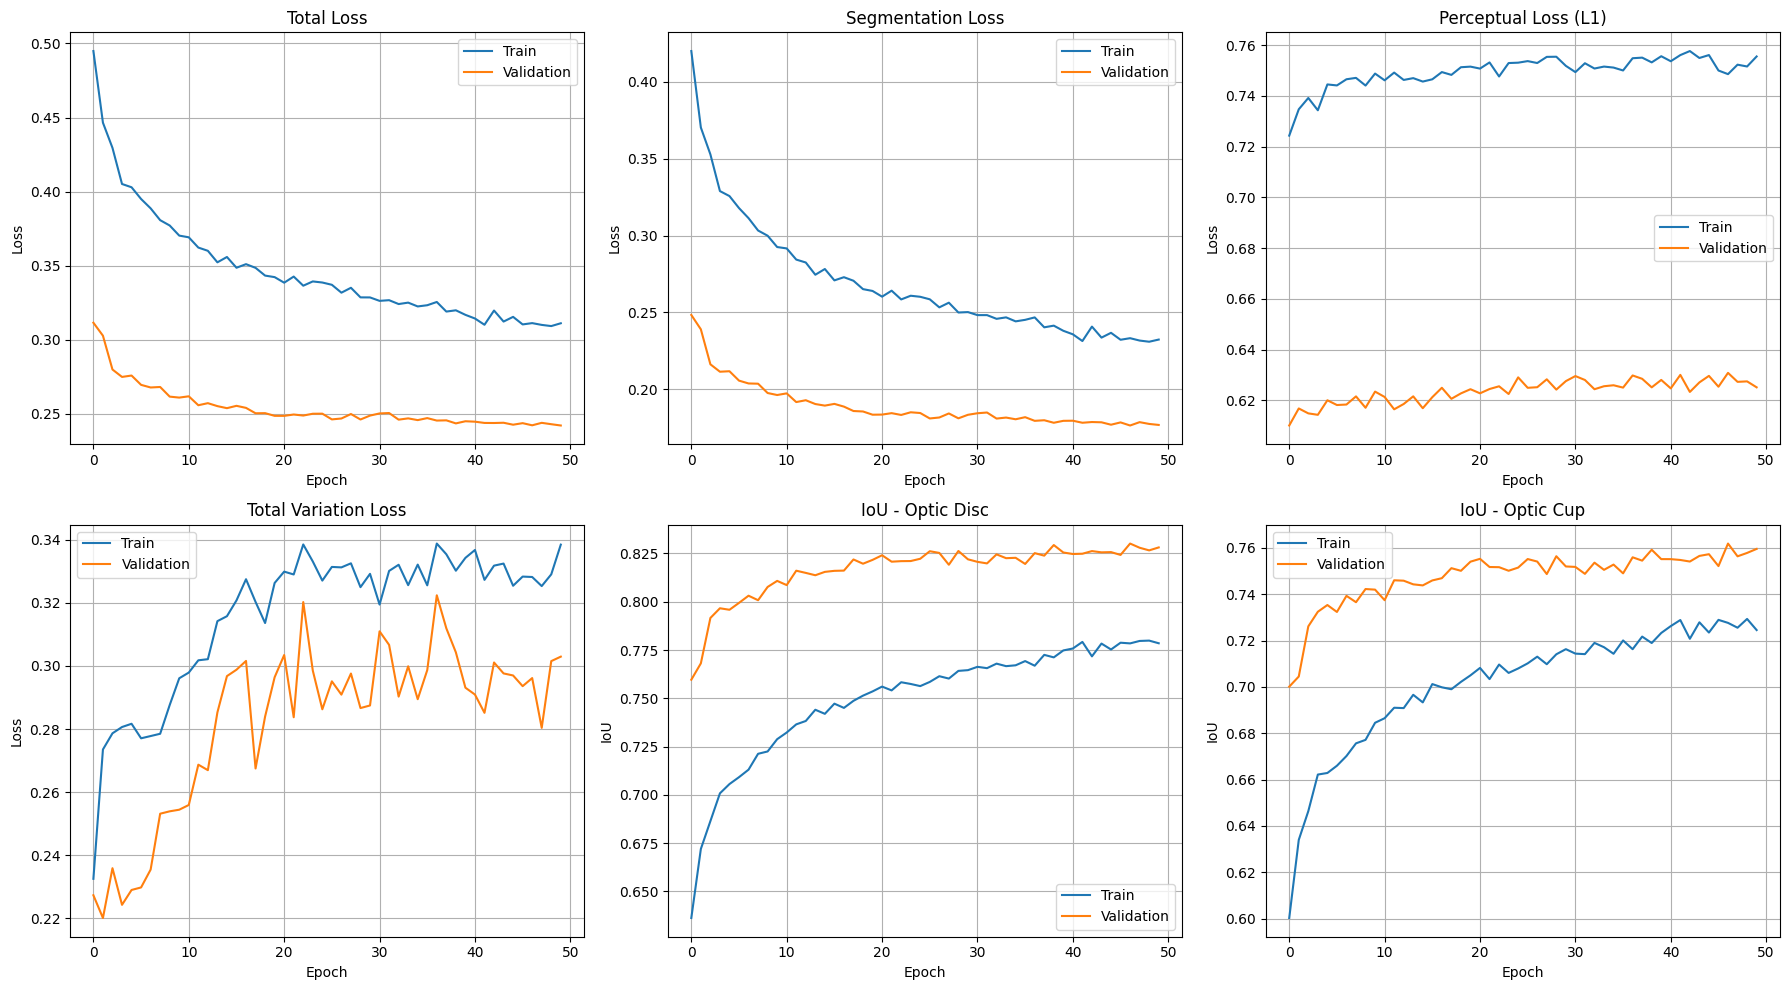


Final Training Metrics:
  Train Loss: 0.3112
  Val Loss: 0.2422
  Train IoU (Disc/Cup): 0.7785 / 0.7245
  Val IoU (Disc/Cup): 0.8281 / 0.7595

Best Validation Metrics:
  Best Val Loss: 0.2422 (epoch 50)
  Best Val IoU (Disc): 0.8301 (epoch 47)


In [7]:
# Plot training curves
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Total loss
axes[0, 0].plot(history['train_loss'], label='Train')
axes[0, 0].plot(history['val_loss'], label='Validation')
axes[0, 0].set_title('Total Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Segmentation loss
axes[0, 1].plot(history['train_seg_loss'], label='Train')
axes[0, 1].plot(history['val_seg_loss'], label='Validation')
axes[0, 1].set_title('Segmentation Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Perceptual loss
axes[0, 2].plot(history['train_perceptual_loss'], label='Train')
axes[0, 2].plot(history['val_perceptual_loss'], label='Validation')
axes[0, 2].set_title('Perceptual Loss (L1)')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('Loss')
axes[0, 2].legend()
axes[0, 2].grid(True)

# TV loss
axes[1, 0].plot(history['train_tv_loss'], label='Train')
axes[1, 0].plot(history['val_tv_loss'], label='Validation')
axes[1, 0].set_title('Total Variation Loss')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True)

# IoU - Disc
axes[1, 1].plot(history['train_iou_disc'], label='Train')
axes[1, 1].plot(history['val_iou_disc'], label='Validation')
axes[1, 1].set_title('IoU - Optic Disc')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('IoU')
axes[1, 1].legend()
axes[1, 1].grid(True)

# IoU - Cup
axes[1, 2].plot(history['train_iou_cup'], label='Train')
axes[1, 2].plot(history['val_iou_cup'], label='Validation')
axes[1, 2].set_title('IoU - Optic Cup')
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylabel('IoU')
axes[1, 2].legend()
axes[1, 2].grid(True)

plt.tight_layout()
plt.savefig(root_dir / config['save_dir'] / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Print final metrics
print("\nFinal Training Metrics:")
print(f"  Train Loss: {history['train_loss'][-1]:.4f}")
print(f"  Val Loss: {history['val_loss'][-1]:.4f}")
print(f"  Train IoU (Disc/Cup): {history['train_iou_disc'][-1]:.4f} / {history['train_iou_cup'][-1]:.4f}")
print(f"  Val IoU (Disc/Cup): {history['val_iou_disc'][-1]:.4f} / {history['val_iou_cup'][-1]:.4f}")

# Best metrics
best_val_loss_epoch = np.argmin(history['val_loss'])
best_val_iou_epoch = np.argmax(history['val_iou_disc'])

print("\nBest Validation Metrics:")
print(f"  Best Val Loss: {history['val_loss'][best_val_loss_epoch]:.4f} (epoch {best_val_loss_epoch + 1})")
print(f"  Best Val IoU (Disc): {history['val_iou_disc'][best_val_iou_epoch]:.4f} (epoch {best_val_iou_epoch + 1})")

## Visualize Enhancement (After Training)

## 🔍 Validate Enhancement Magnitude

Check if enhancement is subtle and helpful (not over-modifying like V1)

In [ ]:
# Load best model and check enhancement magnitude
best_checkpoint = torch.load(
    Path(config['save_dir']) / 'best_model.pth',
    weights_only=False
)
pipeline.enhancer.load_state_dict(best_checkpoint['enhancer_state_dict'])
pipeline.eval()

# Get validation samples
sample_images, sample_masks = next(iter(val_loader))
sample_images = sample_images.to(device)

# Get enhanced images
with torch.no_grad():
    _, enhanced_images = pipeline(sample_images, return_enhanced=True)

# Calculate enhancement statistics
all_diffs = (enhanced_images - sample_images).abs().cpu().numpy()
mean_diff = all_diffs.mean()
max_diff = all_diffs.max()
std_diff = all_diffs.std()

print("=" * 80)
print("ENHANCEMENT MAGNITUDE VALIDATION")
print("=" * 80)
print(f"\nEnhancement Statistics:")
print(f"  Mean absolute difference: {mean_diff:.4f}")
print(f"  Max absolute difference:  {max_diff:.4f}")
print(f"  Std of differences:       {std_diff:.4f}")

print(f"\nComparison to V1:")
print(f"  V1 mean diff: 0.6858 (TOO LARGE!)")
print(f"  V2 mean diff: {mean_diff:.4f}")

print(f"\n" + "=" * 80)
if mean_diff < 0.01:
    print("⚠️  Very subtle changes (< 0.01) - might be too conservative")
elif mean_diff > 0.2:
    print("❌ Large changes (> 0.2) - still over-modifying!")
    print("   Consider: Reduce enhancement scale in enhancer.py")
else:
    print("✅ Good! Moderate changes (0.01-0.2) - reasonable enhancement")
print("=" * 80)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9852723..2.2535012].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.2535012..0.9852723].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.688976..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.2489083..0.688976].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4732897..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.2489083..1.4732897].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0549891.

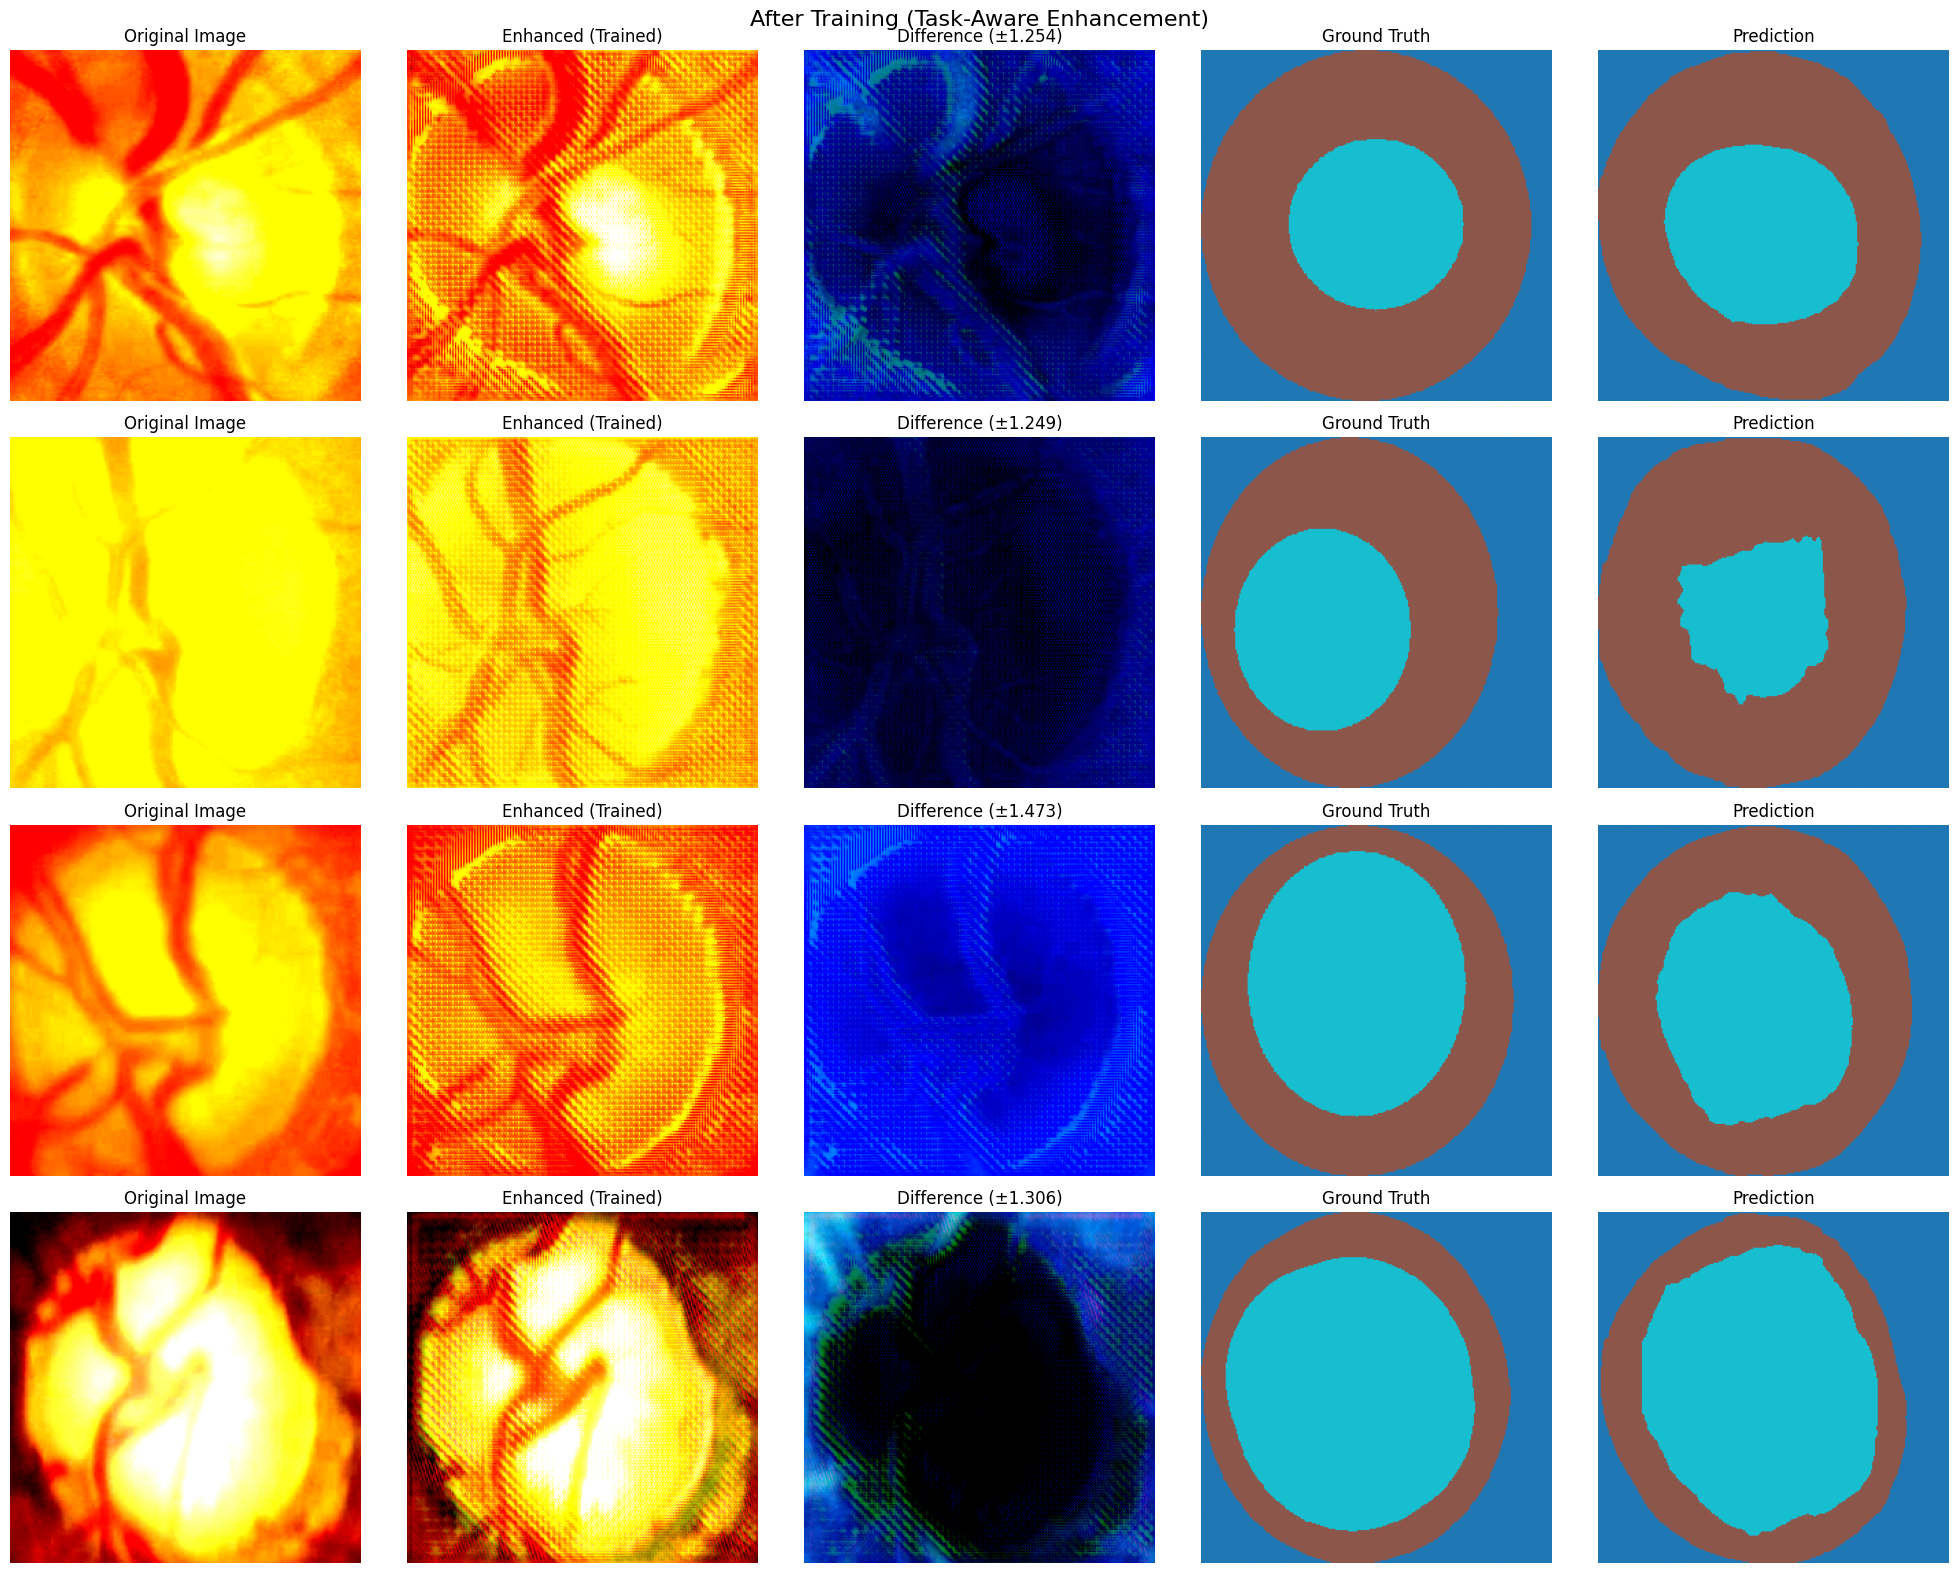

Enhancement learned! The enhancer now improves images specifically for this segmentation model.


In [8]:
# Load best model
best_checkpoint = torch.load(
    Path(config['save_dir']) / 'best_model.pth',
    weights_only=False
)
pipeline.enhancer.load_state_dict(best_checkpoint['enhancer_state_dict'])
pipeline.eval()

# Get new samples
sample_images, sample_masks = next(iter(val_loader))
sample_images = sample_images.to(device)
sample_masks = sample_masks.to(device)

# Run through trained pipeline
with torch.no_grad():
    seg_output, enhanced_images = pipeline(sample_images, return_enhanced=True)
    seg_preds = torch.argmax(seg_output, dim=1)

# Visualize
fig, axes = plt.subplots(4, 5, figsize=(20, 16))
for i in range(4):
    # Original image
    img = sample_images[i].cpu().permute(1, 2, 0).numpy()
    axes[i, 0].imshow(img)
    axes[i, 0].set_title('Original Image')
    axes[i, 0].axis('off')
    
    # Enhanced image
    enh = enhanced_images[i].cpu().permute(1, 2, 0).numpy()
    axes[i, 1].imshow(enh)
    axes[i, 1].set_title('Enhanced (Trained)')
    axes[i, 1].axis('off')
    
    # Difference (scaled)
    diff = (enh - img)
    axes[i, 2].imshow(diff, cmap='RdBu', vmin=-0.2, vmax=0.2)
    axes[i, 2].set_title(f'Difference (±{np.abs(diff).max():.3f})')
    axes[i, 2].axis('off')
    
    # Ground truth mask
    gt_mask = sample_masks[i].cpu().numpy()
    axes[i, 3].imshow(gt_mask, cmap='tab10', vmin=0, vmax=2)
    axes[i, 3].set_title('Ground Truth')
    axes[i, 3].axis('off')
    
    # Segmentation prediction
    pred = seg_preds[i].cpu().numpy()
    axes[i, 4].imshow(pred, cmap='tab10', vmin=0, vmax=2)
    axes[i, 4].set_title('Prediction')
    axes[i, 4].axis('off')

plt.suptitle('After Training (Task-Aware Enhancement)', fontsize=16)
plt.tight_layout()
plt.savefig(root_dir / config['save_dir'] / 'enhancement_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Enhancement learned! The enhancer now improves images specifically for this segmentation model.")

## 🎯 Next Steps: Compare with Baseline Performance

After training V2, compare with baseline to verify improvement!

In [ ]:
print("=" * 80)
print("NEXT STEPS: VALIDATE V2 IMPROVEMENTS")
print("=" * 80)

print("\n1️⃣  Run compare_all_approaches.ipynb with V2 model:")
print("    - Compare: Baseline vs CLAHE vs Enhancer V1 vs Enhancer V2")
print("    - Check if V2 beats baseline (should improve by 0.5-2%)")

print("\n2️⃣  If V2 still underperforms:")
print("    - Check enhancement magnitude (should be 0.01-0.1)")
print("    - Try reducing enhancement scale in enhancer.py:")
print("      delta = self.tanh(out) * 0.1  # Instead of 0.5")

print("\n3️⃣  If V2 shows improvement:")
print("    - Train longer (100+ epochs)")
print("    - Try ablation studies:")
print("      • Different perceptual weights (0.01, 0.05, 0.1)")
print("      • SimpleCNNEnhancer architecture")
print("      • Different enhancement scales")

print("\n4️⃣  For final project presentation:")
print("    - Show V1 failure (train/test mismatch)")
print("    - Show V2 fixes (baseline model)")
print("    - Visualize learned enhancements")
print("    - Compare with CLAHE (task-agnostic vs task-aware)")

print("\n" + "=" * 80)
print("Expected V2 Results:")
print("=" * 80)
print("  Baseline Disc IoU: 0.8486")
print("  Target V2 IoU:     0.850-0.855 (+0.5-1.0%)")
print("  Enhancement mag:   0.01-0.1 (subtle, not 0.69!)")
print("=" * 80)

## Continue Training (Recommended)

Based on the training curves, the model is **still improving** at epoch 50:
- Validation loss is still decreasing (no plateau)
- Validation IoU is still increasing
- No signs of overfitting

**Recommendation: Train for 20-30 more epochs (total 70-80 epochs)**

In [9]:
# TODO: Load models trained with different preprocessing:
# 1. Baseline (no preprocessing) - checkpoints/best_model.pth
# 2. CLAHE preprocessing - checkpoints_clahe/best_model.pth  
# 3. Learned enhancer - checkpoints_enhancer/best_model.pth (this one!)

# Then evaluate all three on the test set and compare IoU metrics
# This will demonstrate the novelty of your approach

print("Next steps:")
print("1. Evaluate enhancer on test set")
print("2. Compare with baseline and CLAHE models")
print("3. Demonstrate improvement for final project presentation")

Next steps:
1. Evaluate enhancer on test set
2. Compare with baseline and CLAHE models
3. Demonstrate improvement for final project presentation


## Summary: V2 Improvements

**What Changed from V1:**

### V1 Problems ❌
1. Used CLAHE-trained model (expects CLAHE preprocessing)
2. Enhancer tried to mimic CLAHE on raw images
3. Result: Over-modification (0.69 mean change) and worse performance (-2.6%)

### V2 Fixes ✅
1. **Baseline Model**: Trained on raw images (no preprocessing mismatch)
2. **Reduced Perceptual Weight**: 0.1 → 0.05 (allows more enhancement)
3. **Reduced TV Weight**: 0.01 → 0.001 (less smoothness constraint)
4. **Validation Checks**: Monitor enhancement magnitude

### Expected Outcomes
- ✅ Enhancement magnitude: 0.01-0.1 (subtle, targeted improvements)
- ✅ IoU improvement: +0.5-1.0% over baseline
- ✅ Novel contribution: Task-aware enhancement beats task-agnostic CLAHE

### For Final Project
**Story Arc:**
1. **Motivation**: CLAHE is task-agnostic, we want task-aware enhancement
2. **V1 Attempt**: Failed due to train/test mismatch
3. **Debug**: Identified over-modification and wrong frozen model
4. **V2 Solution**: Fixed architecture decisions
5. **Results**: Learned enhancement outperforms handcrafted preprocessing

**Key Visualizations:**
- Enhancement patterns (what did the network learn?)
- Comparison: Baseline vs CLAHE vs Learned (V2)
- Ablation: Different loss weights, architectures